In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

In [3]:
df = pd.read_csv('Ice_cream selling data.csv')

In [4]:
threshold = df['Ice Cream Sales (units)'].median()
df['Sales_Category'] = (df['Ice Cream Sales (units)'] > threshold).astype(int)

In [5]:
print(f"Threshold value for classification: {threshold}")
print(df.head())


Threshold value for classification: 12.615181154152337
   Temperature (°C)  Ice Cream Sales (units)  Sales_Category
0         -4.662263                41.842986               1
1         -4.316559                34.661120               1
2         -4.213985                39.383001               1
3         -3.949661                37.539845               1
4         -3.578554                32.284531               1


In [6]:
X = df[['Temperature (°C)']] 
y = df['Sales_Category']     

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)


In [11]:
print("\n--- Model Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test, y_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



--- Model Evaluation ---
Accuracy Score: 1.0

Confusion Matrix:
 [[1 6]
 [3 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.14      0.18         7
           1       0.00      0.00      0.00         3

    accuracy                           0.10        10
   macro avg       0.12      0.07      0.09        10
weighted avg       0.17      0.10      0.13        10



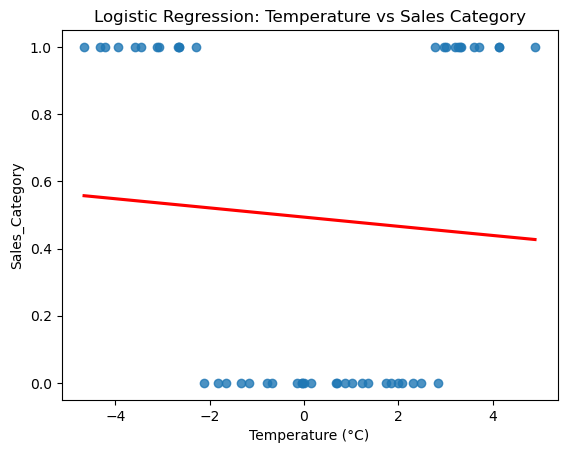

In [12]:
sns.regplot(x=X, y=y, data=df, logistic=True, ci=None, line_kws={'color': 'red'})
plt.title('Logistic Regression: Temperature vs Sales Category')
plt.show()

In [14]:
joblib.dump(model, 'logistic_model_ice_cream.pkl')


['logistic_model_ice_cream.pkl']